# Project: Simple AI-Based Diabetes / Insulin-Resistance Risk Modeling

This project is a **simplified extension of Assignment 1** ("AI-Powered Personalized Dietary Recommender for Insulin Resistance Management").

Instead of using complex CGM + meal logs + RL, we use the **Kaggle Pima Indians Diabetes dataset** as a proxy to:
1. Build a basic **risk prediction model** for diabetes / insulin resistance.
2. Provide a **simple personalized recommendation** based on model output.
3. Add **one new thing** vs. the base paper:  
   - A **PCA-based 2D risk visualisation**, showing how patients cluster in feature space and how risk separates.

---

## Codebook – diabetes.csv (mathchi/diabetes-data-set)

Each row = one patient record (Pima Indian woman, age ≥ 21).  
Target variable: `Outcome` (1 = diabetic / high risk, 0 = non-diabetic / lower risk).

| Column                    | Type      | Description                                                                 |
|---------------------------|-----------|-----------------------------------------------------------------------------|
| Pregnancies               | int       | Number of times the patient has been pregnant.                              |
| Glucose                   | float     | Plasma glucose concentration (2 hours in an oral glucose tolerance test).   |
| BloodPressure             | float     | Diastolic blood pressure (mm Hg).                                          |
| SkinThickness             | float     | Triceps skin fold thickness (mm).                                          |
| Insulin                   | float     | 2-hour serum insulin (mu U/ml).                                            |
| BMI                       | float     | Body Mass Index: weight (kg) / (height (m))².                              |
| DiabetesPedigreeFunction  | float     | Score that describes family history impact on diabetes risk.               |
| Age                       | int       | Age in years.                                                               |
| Outcome                   | int (0/1) | **Target label** – 1 = likely diabetic / insulin-resistant, 0 = otherwise. |

We treat this as a **binary classification** task:  
> Predict `Outcome` from the clinical features, then use the predicted risk to give **simple dietary / lifestyle suggestions** (proxy for a personalized recommender from Assignment 1).


In [2]:
!pip install kaggle

import os, shutil

os.makedirs("/root/.kaggle", exist_ok=True)

shutil.copy("/content/kaggle.json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 0o600)


In [3]:
!kaggle datasets download -d mathchi/diabetes-data-set
!unzip diabetes-data-set.zip -d data


Dataset URL: https://www.kaggle.com/datasets/mathchi/diabetes-data-set
License(s): CC0-1.0
  0% 0.00/8.91k [00:00<?, ?B/s]
100% 8.91k/8.91k [00:00<00:00, 29.1MB/s]
Archive:  diabetes-data-set.zip
  inflating: data/diabetes.csv       


In [5]:
# Imports & basic settings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 120
sns.set(style="whitegrid")


In [7]:
# Load Kaggle diabetes dataset

data_path = "/content/data/diabetes.csv"
df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()


Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
#  Dataset info and basic statistics

print("Data types:\n", df.dtypes, "\n")
print("Missing values per column:\n", df.isna().sum(), "\n")

print("Summary statistics:")
df.describe()


Data types:
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object 

Missing values per column:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64 

Summary statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
#  Replace impossible zeros with NaN and impute with median

cols_with_zero_as_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]

df_clean = df.copy()

for col in cols_with_zero_as_missing:
    zero_count = (df_clean[col] == 0).sum()
    print(f"{col}: {zero_count} zeros replaced with median")
    df_clean.loc[df_clean[col] == 0, col] = np.nan
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

print("\nAny remaining NaNs?\n", df_clean.isna().sum())
df_clean.head()


Glucose: 5 zeros replaced with median
BloodPressure: 35 zeros replaced with median
SkinThickness: 227 zeros replaced with median
Insulin: 374 zeros replaced with median
BMI: 11 zeros replaced with median

Any remaining NaNs?
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


/tmp/ipython-input-3918450744.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].median(), inplace=True)
/tmp/ipython-input-3918450744.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


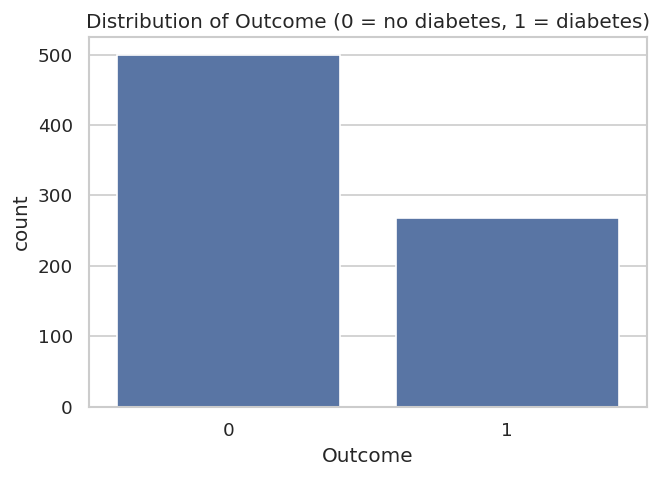

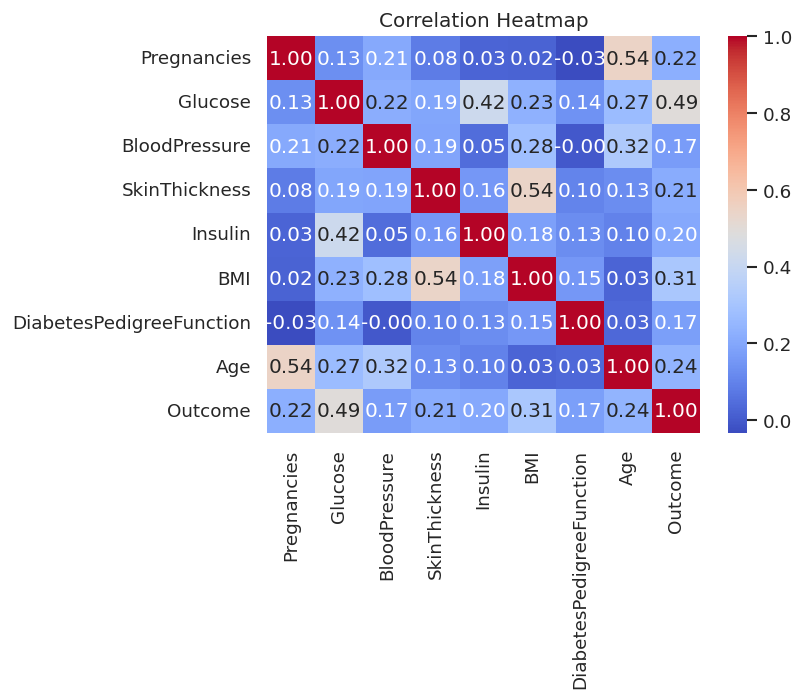

In [10]:
#  Exploratory analysis – correlations and target distribution

# Histogram of Outcome
plt.figure()
sns.countplot(x="Outcome", data=df_clean)
plt.title("Distribution of Outcome (0 = no diabetes, 1 = diabetes)")
plt.show()

# Correlation heatmap
plt.figure(figsize=(7,6))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [11]:
#  Train–test split and feature scaling

X = df_clean.drop("Outcome", axis=1).values
y = df_clean["Outcome"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train size: 614  Test size: 154


Explained variance by components: [0.29429594 0.18786978]


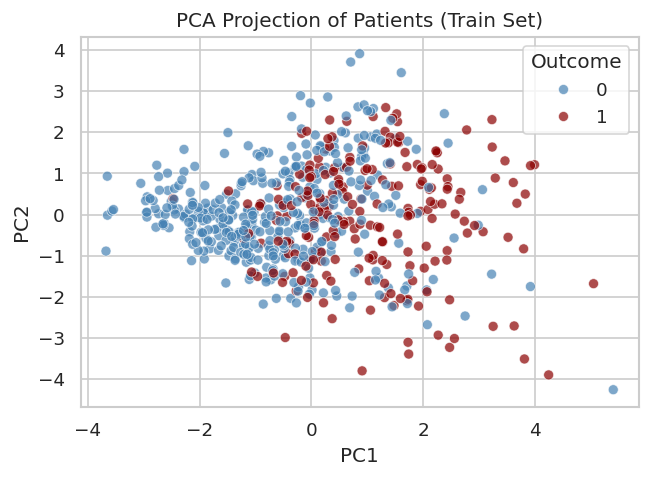

In [12]:
#  PCA for 2D visualization (new thing)

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Explained variance by components:", pca.explained_variance_ratio_)

plt.figure()
sns.scatterplot(
    x=X_train_pca[:, 0],
    y=X_train_pca[:, 1],
    hue=y_train,
    palette=["steelblue", "darkred"],
    alpha=0.7,
)
plt.title("PCA Projection of Patients (Train Set)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Outcome")
plt.show()


In [13]:
#  Logistic Regression model (baseline risk model)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]  # probability of Outcome=1

def evaluate_classifier(name, y_true, y_pred):
    print(f"=== {name} ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-score :", f1_score(y_true, y_pred))
    print()

evaluate_classifier("Logistic Regression", y_test, y_pred_log)
print("Classification report:\n", classification_report(y_test, y_pred_log))


=== Logistic Regression ===
Accuracy : 0.7077922077922078
Precision: 0.6
Recall   : 0.5
F1-score : 0.5454545454545454

Classification report:
               precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [14]:
#  Random Forest classifier (non-linear baseline)

rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)
rf_clf.fit(X_train_scaled, y_train)

y_pred_rf = rf_clf.predict(X_test_scaled)
y_proba_rf = rf_clf.predict_proba(X_test_scaled)[:, 1]

evaluate_classifier("Random Forest", y_test, y_pred_rf)
print("Classification report:\n", classification_report(y_test, y_pred_rf))


=== Random Forest ===
Accuracy : 0.7402597402597403
Precision: 0.6521739130434783
Recall   : 0.5555555555555556
F1-score : 0.6

Classification report:
               precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



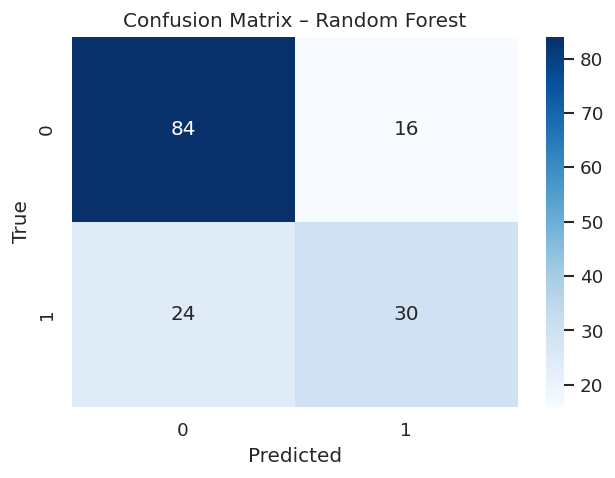

In [15]:
#  Confusion matrix for Random Forest (can swap to log_reg if you prefer)

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Random Forest")
plt.show()


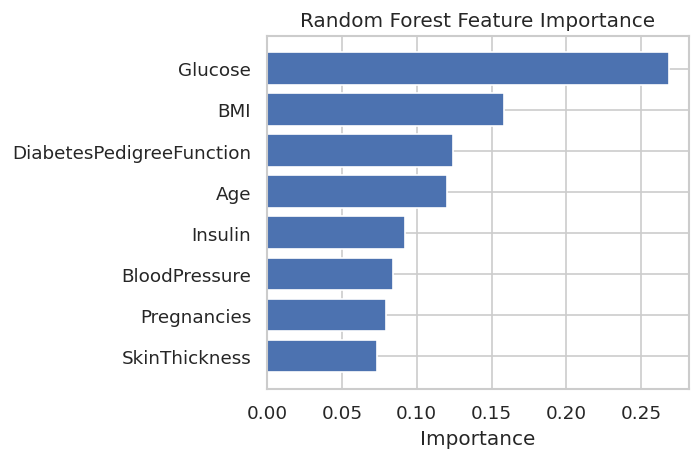

Glucose                  : 0.268
BMI                      : 0.158
DiabetesPedigreeFunction : 0.124
Age                      : 0.120
Insulin                  : 0.092
BloodPressure            : 0.084
Pregnancies              : 0.079
SkinThickness            : 0.073


In [16]:
# Feature importance from Random Forest

feature_names = df_clean.drop("Outcome", axis=1).columns
importances = rf_clf.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(6,4))
plt.barh(range(len(feature_names)), importances[sorted_idx])
plt.yticks(range(len(feature_names)), feature_names[sorted_idx])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

for name, imp in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True):
    print(f"{name:25s}: {imp:.3f}")


In [18]:
#  Simple personalized risk + lifestyle recommendation
# This fills the "recommender" gap from Assignment 1 in a simple way.

def assess_patient_risk(patient_row, model=rf_clf, scaler=scaler, thresh_low=0.3, thresh_high=0.7):
    """
    patient_row: dict with keys matching dataset columns (except Outcome).
                 e.g. {"Pregnancies": 2, "Glucose": 140, ...}
    model: trained classifier with predict_proba
    Returns: probability of diabetes and a simple recommendation string.
    """
    # Ensure correct order of features
    ordered_features = df_clean.drop("Outcome", axis=1).columns
    row_df = pd.DataFrame([patient_row])[ordered_features]

    # Scale using training scaler
    row_scaled = scaler.transform(row_df)
    prob = model.predict_proba(row_scaled)[0, 1]  # probability of diabetes

    # Basic interpretation
    if prob < thresh_low:
        risk_level = "LOW"
        advice = (
            "Your predicted diabetes risk is LOW. "
            "Maintain current habits: balanced diet, regular activity, and weight control."
        )
    elif prob < thresh_high:
        risk_level = "MODERATE"
        advice = (
            "Your predicted diabetes risk is MODERATE. "
            "Focus on improving diet quality (more fiber, fewer refined carbs) "
            "and increasing daily physical activity."
        )
    else:
        risk_level = "HIGH"
        advice = (
            "Your predicted diabetes risk is HIGH. "
            "Consider consulting a doctor, reducing sugar and refined carbohydrate intake, "
            "controlling BMI, and increasing regular exercise."
        )

    return prob, risk_level, advice

# Example manual patient (you can modify values)
example_patient = {
    "Pregnancies": 2,
    "Glucose": 145,
    "BloodPressure": 80,
    "SkinThickness": 25,
    "Insulin": 100,
    "BMI": 32.0,
    "DiabetesPedigreeFunction": 0.5,
    "Age": 35,
}

prob, level, text = assess_patient_risk(example_patient)
print("Example patient:", example_patient)
print(f"Predicted diabetes risk probability: {prob:.3f}")
print("Risk level:", level)
print("Recommendation:", text)


Example patient: {'Pregnancies': 2, 'Glucose': 145, 'BloodPressure': 80, 'SkinThickness': 25, 'Insulin': 100, 'BMI': 32.0, 'DiabetesPedigreeFunction': 0.5, 'Age': 35}
Predicted diabetes risk probability: 0.460
Risk level: MODERATE
Recommendation: Your predicted diabetes risk is MODERATE. Focus on improving diet quality (more fiber, fewer refined carbs) and increasing daily physical activity.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
